In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [14]:
df = pd.read_csv('car_price.csv')
print("Размер датасета:", df.shape)
print("\nПервые строки:")
display(df.head())
print("\nТипы данных:")
print(df.dtypes)
print("\nПропущенные значения:")
print(df.isnull().sum())
print("\nОписание числовых признаков:")
display(df.describe())

Размер датасета: (205, 26)

Первые строки:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0



Типы данных:
car_ID                int64
symboling             int64
CarName                 str
fueltype                str
aspiration              str
doornumber              str
carbody                 str
drivewheel              str
enginelocation          str
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype              str
cylindernumber          str
enginesize            int64
fuelsystem              str
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

Пропущенные значения:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
c

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [15]:
# Извлекаем название бренда из CarName
df['brand'] = df['CarName'].str.split().str[0].str.lower()

# Исправляем опечатки в названиях брендов
brand_fix = {
    'vw': 'volkswagen', 'vokswagen': 'volkswagen',
    'toyouta': 'toyota', 'maxda': 'mazda',
    'porcshce': 'porsche', 'alfa-romero': 'alfa-romeo'
}
df['brand'] = df['brand'].replace(brand_fix)

# Удаляем оригинальную колонку CarName и car_ID
df.drop(['CarName', 'car_ID'], axis=1, inplace=True)

print("Уникальные бренды:", sorted(df['brand'].unique()))

Уникальные бренды: ['alfa-romeo', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


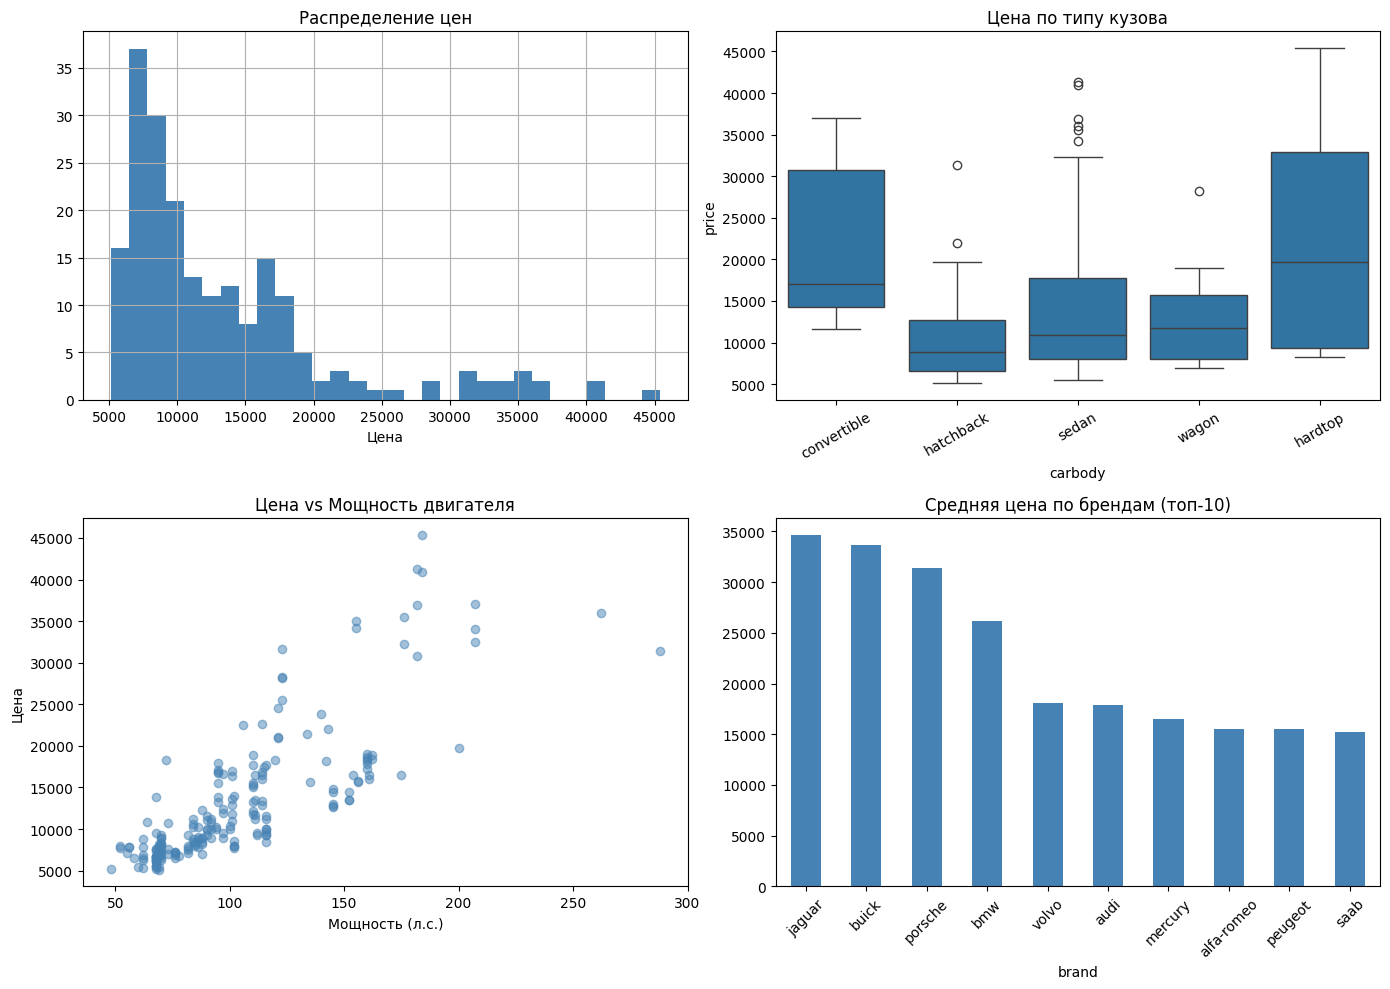

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение цен
df['price'].hist(bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Распределение цен')
axes[0,0].set_xlabel('Цена')

# Цена по типу кузова
sns.boxplot(data=df, x='carbody', y='price', ax=axes[0,1])
axes[0,1].set_title('Цена по типу кузова')
axes[0,1].tick_params(axis='x', rotation=30)

# Цена vs мощность двигателя
axes[1,0].scatter(df['horsepower'], df['price'], alpha=0.5, color='steelblue')
axes[1,0].set_title('Цена vs Мощность двигателя')
axes[1,0].set_xlabel('Мощность (л.с.)')
axes[1,0].set_ylabel('Цена')

# Средняя цена по брендам (топ-10)
brand_price = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)
brand_price.plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Средняя цена по брендам (топ-10)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

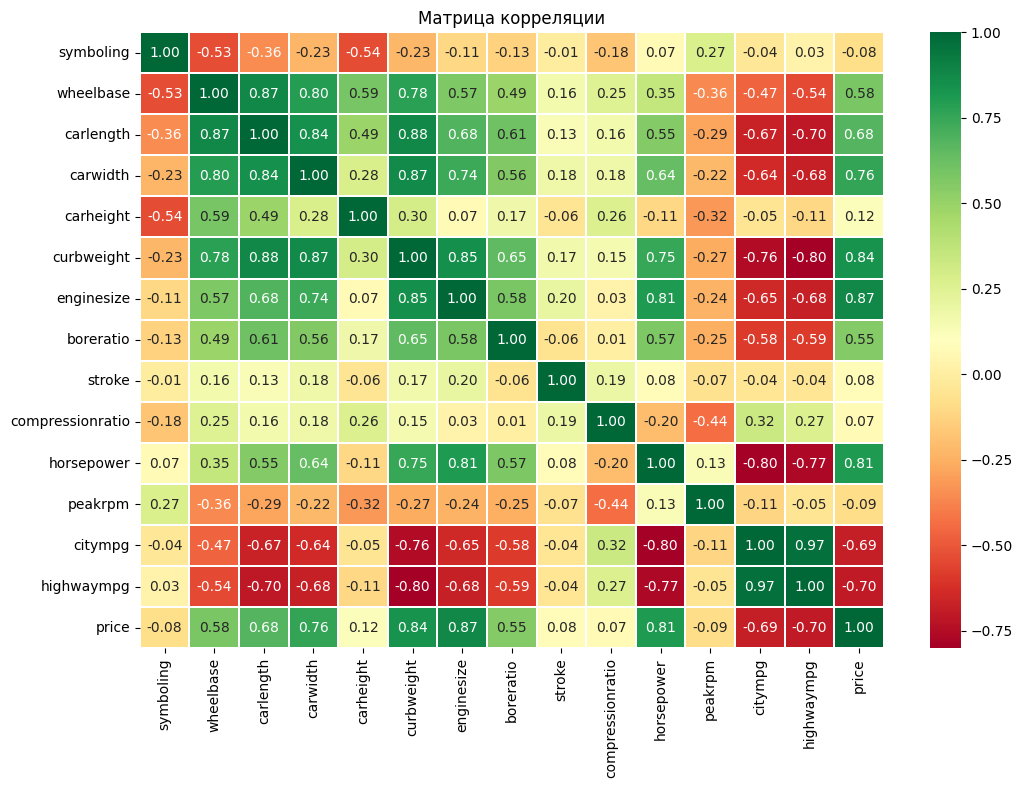

In [17]:
numeric_cols = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.2)
plt.title('Матрица корреляции')
plt.show()

In [18]:
# Кодируем категориальные признаки
cat_cols = df.select_dtypes(include=['object']).columns
print("Категориальные признаки:", list(cat_cols))

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("\nРазмер после кодирования:", df_encoded.shape)

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

Категориальные признаки: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']

Размер после кодирования: (205, 65)


In [19]:
from sklearn.linear_model import LinearRegression

scaler_rfe = StandardScaler()
X_scaled_rfe = scaler_rfe.fit_transform(X)

rfe = RFE(estimator=LinearRegression(), n_features_to_select=15)
rfe.fit(X_scaled_rfe, y)

selected_features = X.columns[rfe.support_]
print("Отобранные признаки RFE:")
print(list(selected_features))

X = X[selected_features]

Отобранные признаки RFE:
['wheelbase', 'carlength', 'carwidth', 'curbweight', 'enginesize', 'peakrpm', 'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'enginelocation_rear', 'enginetype_l', 'brand_bmw', 'brand_buick', 'brand_peugeot', 'brand_porsche']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train размер:", X_train_scaled.shape)
print("Test размер:", X_test_scaled.shape)

Train размер: (164, 15)
Test размер: (41, 15)


In [21]:
def gradient_descent(X, y, lr=0.01, alpha=1.0, n_iter=1000):
    """
    Batch Gradient Descent с L2-регуляризацией (MSE + L2).
    X: матрица признаков (уже со столбцом единиц для bias)
    y: целевой вектор
    lr: learning rate
    alpha: коэффициент L2-регуляризации
    n_iter: количество итераций
    Возвращает вектор весов w.
    """
    n = X.shape[0]
    # Добавляем столбец единиц для свободного члена
    X_b = np.c_[np.ones(n), X]
    w = np.zeros(X_b.shape[1])

    for _ in range(n_iter):
        y_pred = X_b @ w
        error = y_pred - y
        # Градиент MSE + L2 (не регуляризуем bias — w[0])
        grad = (2 / n) * (X_b.T @ error)
        grad[1:] += 2 * alpha * w[1:]
        w -= lr * grad

    return w


def predict_gd(X, w):
    X_b = np.c_[np.ones(X.shape[0]), X]
    return X_b @ w


def scores(y_true, y_pred, label=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{label}  MSE={mse:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}")
    return mse, rmse, r2

In [22]:
# Подбор гиперпараметров для GD через ручной поиск
best_rmse = np.inf
best_params = {}

for lr in [0.001, 0.005, 0.01]:
    for alpha in [0.1, 1.0, 10.0]:
        w = gradient_descent(X_train_scaled, y_train.values, lr=lr, alpha=alpha, n_iter=2000)
        y_pred_val = predict_gd(X_train_scaled, w)
        rmse = np.sqrt(mean_squared_error(y_train, y_pred_val))
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = {'lr': lr, 'alpha': alpha}

print("Лучшие параметры GD:", best_params)

w_gd = gradient_descent(X_train_scaled, y_train.values,
                        lr=best_params['lr'], alpha=best_params['alpha'], n_iter=2000)

y_pred_train_gd = predict_gd(X_train_scaled, w_gd)
y_pred_test_gd  = predict_gd(X_test_scaled, w_gd)

print("\n--- Gradient Descent ---")
scores(y_train, y_pred_train_gd, "Train:")
scores(y_test,  y_pred_test_gd,  "Test: ")

# Ridge из sklearn
alpha_grid = np.logspace(-2, 4, 20)
grid = GridSearchCV(Ridge(), [{"alpha": alpha_grid}],
                    scoring="neg_root_mean_squared_error", cv=5)
grid.fit(X_train_scaled, y_train)
best_alpha = grid.best_params_['alpha']
print(f"\nLучший alpha для Ridge: {best_alpha:.4f}")

ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train_scaled, y_train)

print("\n--- Ridge (sklearn) ---")
scores(y_train, ridge.predict(X_train_scaled), "Train:")
scores(y_test,  ridge.predict(X_test_scaled),  "Test: ")

Лучшие параметры GD: {'lr': 0.01, 'alpha': 0.1}

--- Gradient Descent ---
Train:  MSE=3873037.38  RMSE=1968.00  R2=0.9351
Test:   MSE=9708678.03  RMSE=3115.88  R2=0.8770

Lучший alpha для Ridge: 6.9519

--- Ridge (sklearn) ---
Train:  MSE=3635795.74  RMSE=1906.78  R2=0.9390
Test:   MSE=9838061.00  RMSE=3136.57  R2=0.8754


(9838060.997751703, np.float64(3136.568347374516), 0.8753792765034245)

In [23]:
def sgd(X, y, lr=0.01, alpha=1.0, n_iter=1000):
    """Stochastic Gradient Descent с L2."""
    n = X.shape[0]
    X_b = np.c_[np.ones(n), X]
    w = np.zeros(X_b.shape[1])
    for _ in range(n_iter):
        for i in np.random.permutation(n):
            xi = X_b[i]          # просто вектор, не матрица
            yi = y[i]
            error = xi @ w - yi
            grad = 2 * xi * error
            grad[1:] += 2 * alpha * w[1:]
            w -= lr * grad
    return w


def mini_batch_gd(X, y, lr=0.01, alpha=1.0, n_iter=1000, batch_size=32):
    """Mini-Batch Gradient Descent с L2."""
    n = X.shape[0]
    X_b = np.c_[np.ones(n), X]
    w = np.zeros(X_b.shape[1])
    for _ in range(n_iter):
        indices = np.random.permutation(n)
        for start in range(0, n, batch_size):
            idx = indices[start:start+batch_size]
            Xi = X_b[idx]
            yi = y[idx]
            error = Xi @ w - yi
            grad = (2 / len(idx)) * (Xi.T @ error)
            grad[1:] += 2 * alpha * w[1:]
            w -= lr * grad
    return w


w_sgd = sgd(X_train_scaled, y_train.values, lr=0.001, alpha=1.0, n_iter=100)
w_mbgd = mini_batch_gd(X_train_scaled, y_train.values, lr=0.005, alpha=1.0, n_iter=200, batch_size=32)

print("--- SGD ---")
scores(y_train, predict_gd(X_train_scaled, w_sgd), "Train:")
scores(y_test,  predict_gd(X_test_scaled, w_sgd),  "Test: ")

print("\n--- Mini-Batch GD ---")
scores(y_train, predict_gd(X_train_scaled, w_mbgd), "Train:")
scores(y_test,  predict_gd(X_test_scaled, w_mbgd),  "Test: ")

--- SGD ---
Train:  MSE=8028116.45  RMSE=2833.39  R2=0.8654
Test:   MSE=12968987.39  RMSE=3601.25  R2=0.8357

--- Mini-Batch GD ---
Train:  MSE=7912484.63  RMSE=2812.91  R2=0.8673
Test:   MSE=12180467.06  RMSE=3490.05  R2=0.8457


(12180467.05921833, np.float64(3490.052586884377), 0.8457075415782755)

In [24]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

results = {
    'GD': {'mse_train': [], 'mse_test': [], 'rmse_train': [], 'rmse_test': [], 'r2_train': [], 'r2_test': []},
    'Ridge': {'mse_train': [], 'mse_test': [], 'rmse_train': [], 'rmse_test': [], 'r2_train': [], 'r2_test': []},
}

X_arr = X.values
y_arr = y.values

for train_idx, test_idx in kf.split(X_arr):
    Xtr, Xte = X_arr[train_idx], X_arr[test_idx]
    ytr, yte = y_arr[train_idx], y_arr[test_idx]

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    # GD
    w = gradient_descent(Xtr_s, ytr, lr=best_params['lr'], alpha=best_params['alpha'], n_iter=2000)
    for key, (yt, yp) in zip(
        ['train', 'test'],
        [(ytr, predict_gd(Xtr_s, w)), (yte, predict_gd(Xte_s, w))]
    ):
        mse = mean_squared_error(yt, yp)
        results['GD'][f'mse_{key}'].append(mse)
        results['GD'][f'rmse_{key}'].append(np.sqrt(mse))
        results['GD'][f'r2_{key}'].append(r2_score(yt, yp))

    # Ridge
    r = Ridge(alpha=best_alpha).fit(Xtr_s, ytr)
    for key, (yt, yp) in zip(
        ['train', 'test'],
        [(ytr, r.predict(Xtr_s)), (yte, r.predict(Xte_s))]
    ):
        mse = mean_squared_error(yt, yp)
        results['Ridge'][f'mse_{key}'].append(mse)
        results['Ridge'][f'rmse_{key}'].append(np.sqrt(mse))
        results['Ridge'][f'r2_{key}'].append(r2_score(yt, yp))

# Строим таблицу
for model_name, res in results.items():
    print(f"\n=== {model_name} ===")
    rows = ['mse_train', 'mse_test', 'rmse_train', 'rmse_test', 'r2_train', 'r2_test']
    cols = [f'Fold{i+1}' for i in range(k)] + ['E (mean)', 'STD']
    data = []
    for row in rows:
        vals = res[row]
        data.append(vals + [np.mean(vals), np.std(vals)])
    table = pd.DataFrame(data, index=rows, columns=cols)
    display(table.round(2))


=== GD ===


,Fold1,Fold2,Fold3,Fold4,Fold5,E (mean),STD
mse_train,3873037.38,4868184.35,4867306.59,5152444.78,4094974.88,4571189.60,495569.51
mse_test,9708678.03,3857792.30,4128349.78,4007688.09,7578332.54,5856168.15,2375012.57
rmse_train,1968.00,2206.40,2206.20,2269.90,2023.60,2134.82,117.18
rmse_test,3115.88,1964.13,2031.83,2001.92,2752.88,2373.33,472.75
r2_train,0.94,0.93,0.93,0.92,0.93,0.93,0.01
r2_test,0.88,0.90,0.92,0.94,0.90,0.91,0.02



=== Ridge ===


,Fold1,Fold2,Fold3,Fold4,Fold5,E (mean),STD
mse_train,3635795.74,4546626.53,4597976.52,4924522.53,3849445.11,4310873.28,486460.46
mse_test,9838061.00,4075711.18,4439468.90,3391284.75,7369226.16,5822750.40,2424538.94
rmse_train,1906.78,2132.28,2144.29,2219.13,1962.00,2072.89,118.24
rmse_test,3136.57,2018.84,2107.00,1841.54,2714.63,2363.72,485.38
r2_train,0.94,0.93,0.93,0.92,0.94,0.93,0.01
r2_test,0.88,0.89,0.91,0.95,0.90,0.91,0.03
